In [103]:





#의료 기초 데이터 분석 미니 프로젝트
#numpy + pandas +Matplotlib

In [104]:
#============================
#[0] 라이브러리 import, 출력 옵션
#============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [105]:
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 200)

In [106]:
# ==============================
# # [1] 데이터 준비
# ==============================
data = {
    "측정일": [
        '2026-02-01','2026-02-01','2026-02-02',"2026-02-02","2026-02-03",
        "2026-02-03","2026-02-04","2026-02-04","2026-02-05","2026-02-05",
        "2026-02-06","2026-02-06","2026-02-07","2026-02-07","2026-02-08"
    ],
    "환자ID": [
        "P001","P002","P003","P004","P005",
        "P006","P007","P008","P009","P010",
        "P011","P012","P013","P014","P015"
    ],
    "성별": ["F","M","M","F","F","M","M","F","F","M","F","M","M","F","F"],
    "나이":  [25, 31, 44, np.nan, 52, 39, 28, 33, 47, 61, 29, 42, np.nan, 36, 55],
    "키":    ["162cm","175cm","168cm","160cm","158cm","180cm","172cm","165cm","170cm","177cm","159cm","174cm","169cm","163cm","157cm"],
    "몸무게": ["54kg","78kg","70kg","52kg","60kg","90kg","68kg","58kg","73kg","82kg","50kg","76kg","71kg","57kg","66kg"],
    "SBP(수축기)": [108, 135, 142, 118, 150, 130, 125, 112, 140, 160, 105, 138, 145, 120, 155],
    "DBP(이완기)": [ 70,  88,  92,  75,  95,  85,  80,  72,  90, 100,  68,  89,  96,  78,  97],
    "심박수":      [72,  84,  90,  68,  95,  78,  70,  75,  88,  92,  66,  80,  86,  73,  89],
    "공복혈당":    [92,  110, 125,  98, 130, np.nan, 105,  90, 118, 140,  88, 112, 128, 100, np.nan],
    "흡연":        ["N","Y","Y","N","N","Y","N","N","Y","Y","N","Y","Y","N","N"],
    "운동빈도(주)": [3, 1, 0, 2, np.nan, 1, 4, 2, 1, 0, 5, 1, 0, 3, np.nan],
}
df = pd.DataFrame(data)

In [107]:
# ==============================
# [2] 데이터 탐색
# ==============================

print('========================')
print('2)데이터 탐색')
print('========================')

print("\n[head()]")
print(df.head())

print("\n[info()] (데이터 구조 확인)")
print(df.info())

print("\n[describe()] (숫자 컬럼 요약)")
num_cols = ["나이", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)"]
print(df[num_cols].describe())


2)데이터 탐색

[head()]
       측정일 환자ID 성별  나이     키 몸무게  SBP(수축기)  DBP(이완기)  심박수  공복혈당 흡연  운동빈도(주)
0  2026-02-01   P001    F  25.0  162cm   54kg          108           70      72      92.0    N           3.0
1  2026-02-01   P002    M  31.0  175cm   78kg          135           88      84     110.0    Y           1.0
2  2026-02-02   P003    M  44.0  168cm   70kg          142           92      90     125.0    Y           0.0
3  2026-02-02   P004    F   NaN  160cm   52kg          118           75      68      98.0    N           2.0
4  2026-02-03   P005    F  52.0  158cm   60kg          150           95      95     130.0    N           NaN

[info()] (데이터 구조 확인)
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   측정일       15 non-null     str    
 1   환자ID      15 non-null     str    
 2   성별        15 non-null     str    
 3   나이        13 non-null     float64
 4   키      

In [108]:
# ==============================
# [3] 데이터 정제 및 변환
# ==============================
print("==============================")
print("3) 데이터 정제 및 변환")
print("==============================")
# ---------------------------------------------
# 3-1) 타입 변환 : 날짜 문자열 -> datetime
# ---------------------------------------------
# pd.to_datetime(): 문자열을 날짜/시간 타입으로 변환
df["측정일"] = pd.to_datetime(df["측정일"])

# ---------------------------------------------
# 3-2) 단위 제거 : "170cm" -> 170, "65kg" -> 65
# ---------------------------------------------
# str.replace() : 문자열 치환(여기서는 단위 제거)
# astype(int) : 숫자형으로 변환 
df["키_cm"] = df["키"].str.replace("cm", "", regex=False).astype(int)
df["몸무게_kg"] = df["몸무게"].str.replace("kg", "", regex=False).astype(int) 
#원본(키, 몸무게) 컬럼은 '문자열'이라서 분석에 불리하므로 
#보통 숫자형 칼럼(키_cm, 몸무게_kg)만 쓰는 편 

# ---------------------------------------------
# 3-3) 결측치 확인
# ---------------------------------------------
print("\n[결측치 개수 확인]")
print(df.isnull().sum()) 

# ---------------------------------------------
# 3-4) 결측치 처리 (예시)
# ---------------------------------------------
'''
결측치 처리 방식은 정답이 1개가 아니라, 상황에 따라 다름
- 나이 : 평균으로 채울
- 공복혈당 : 중앙값으로 채울(극단값 영향을 줄이고 싶을 때)
- 운동빈도 : 0으로 채움(운동 기록이 없으면 0으로 가정하는 경우)
'''
df["나이"] = df["나이"].fillna(df["나이"].mean())
df["공복혈당"] = df["공복혈당"].fillna(df["공복혈당"].median()) # 중앙값
df["운동빈도(주)"] = df["운동빈도(주)"].fillna(0)
# ---------------------------------------------
# 3-5) 파생 컬럼 생성(변환)
# ---------------------------------------------
# BMI = 몸무게(kg) / (키(m)^2)
df["키_m"] = df["키_cm"] / 100
df["BMI"] = df["몸무게_kg"] / (df["키_m"] ** 2)
# 맥박압(PP) = SBP - DBP (혈관 탄성/압력 차이를 보는 간단 지표)
df["맥박압_PP"] = df["SBP(수축기)"] - df["DBP(이완기)"]

# 평균동맥압("MAP") = (SBP + 2*DBP) / 3 (기초적인 참고 지표)
df["평균동맥압_MAP"] = (df["SBP(수축기)"] + 2 * df["DBP(이완기)"]) / 3 

# ---------------------------------------------
# 3-6) 범주화(카테고리 만들기) : 혈압 단계 분류
# ---------------------------------------------
'''
기준(간단 버전)
- 정상 : SBP < 120 그리고 DBP < 80
- 주의(상승) : SBP 120~129 그리고 DBP < 80
- 고혈압1기 : SBP 130~139 또는 DBP 80~89
- 고혈압2기 : SBP >= 140 또는 DBP >= 90
'''
#연쇄비교문법 120 <= sbp <= 129
def bp_category(sbp, dbp):
    if (sbp < 120) and (dbp < 80):
        return "정상"
    elif (120 <= sbp <= 129) and (dbp < 80):
        return "주의(상승)"
    elif (130 <= sbp <= 139) or (80 <= dbp <= 89):
        return "고혈압1기"
    elif (sbp >= 140) or (dbp >= 90):
        return "고혈압2기"
    else:
        return "기타"
    
# apply() : 행 단위로 함수를 적용할 때 자주 사용
# lambda row : 익명 함수(이름 없는 함수)
# lambda 입력값 : 계산식
df["혈압분류"] = df.apply(lambda row: bp_category(row["SBP(수축기)"], row["DBP(이완기)"]), axis=1)


# ---------------------------------------------
# 3-7) 범주화 : BMI 단계 분류(간단 예시)
# ---------------------------------------------
'''
BMI 분류
- 저체중 : < 18.5
- 정상 : 18.5 ~ 22.9
- 과체중 : 23.0 ~ 24.9
- 비만 : >= 25.0
'''
def bmi_category(bmi):
    if bmi < 18.5:
        return "저체중"
    elif bmi < 23.0:
        return "정상"
    elif bmi < 25.0:
        return "과체중"
    else:
        return "비만"

df["BMI분류"] = df["BMI"].apply(bmi_category)

print("\n[정제/변환 결과 미리보기]")
show_cols = show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
print(df[show_cols].head(14))

3) 데이터 정제 및 변환

[결측치 개수 확인]
측정일          0
환자ID          0
성별            0
나이            2
키              0
몸무게          0
SBP(수축기)     0
DBP(이완기)     0
심박수          0
공복혈당        2
흡연            0
운동빈도(주)    2
키_cm           0
몸무게_kg       0
dtype: int64

[정제/변환 결과 미리보기]
       측정일 환자ID 성별       나이  키_cm  몸무게_kg  SBP(수축기)  DBP(이완기)  공복혈당  운동빈도(주)        BMI    혈압분류 BMI분류
0  2026-02-01   P001    F  25.000000    162         54          108           70      92.0           3.0  20.576132        정상    정상
1  2026-02-01   P002    M  31.000000    175         78          135           88     110.0           1.0  25.469388   고혈압1기    비만
2  2026-02-02   P003    M  44.000000    168         70          142           92     125.0           0.0  24.801587   고혈압2기  과체중
3  2026-02-02   P004    F  40.153846    160         52          118           75      98.0           2.0  20.312500        정상    정상
4  2026-02-03   P005    F  52.000000    158         60          150           95     130.0           0

In [109]:
# ==============================
# [4] 분석
# ==============================
print("==============================")
print("4) 분석" )
print("==============================")
# ---------------------------------------------
# 4-1) 최고/최저 : BMI가 가장 높은/낮은 사람
# ---------------------------------------------
max_bmi_row = df.loc[df["BMI"].idxmax()] # 최댓값 위치 반환
min_bmi_row = df.loc[df["BMI"].idxmin()] # 최솟값 위치 반환

print("\n[BMI 최고]")
print(max_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]])
print("\n[BMI 최저]")
print(min_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]]) 

# ---------------------------------------------
# 4-2)혈압 분류별 평균 지표
# ---------------------------------------------
#groupby: 같은 분류별로 모으는 것 
bp_group = df.groupby("혈압분류")[["SBP(수축기)", "DBP(이완기)", "맥박압_PP", "평균동맥압_MAP", "BMI", "공복혈당"]].mean().sort_values("SBP(수축기)", ascending=False)

print("\n[혈압 분류별 평균]")
print(bp_group)
# ---------------------------------------------
# 4-3) 성별  평균 지표
# ---------------------------------------------
gender_group = df.groupby("성별")[["SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "BMI", "운동빈도(주)"]].mean() 
print("\n[성별 평균 비교]")
print(gender_group)

# ---------------------------------------------
# 4-4) 나이대(연령대) 만들기 + 그룹평균
# ---------------------------------------------
''' 
나이대는 분석에서 자주 사용
-pd.cut():숫자를 구간으로 나눠 범주형 컬럼 생성
'''
bins = [0,19,39,49,59,120]
labels = ["20대","30대","40대","50대","60대 이상"]
df["나이대"] = pd.cut(df["나이"], bins=bins, labels=labels, right=True) 

age_group = df.groupby("나이대")[["SBP(수축기)", "DBP(이완기)", "공복혈당", "BMI"]].mean()
print("\n[나이대별 평균]")
print(age_group)

# ---------------------------------------------
# 4-5) 상관관계(수치형 칼럼)
# ---------------------------------------------
''' 
corr():상관계수(-1~1)
- 1에 가까울수록 같이 오르는 경향 (양의 상관)
- -1에 가까울수록 반대로 움직이는 경향 (음의 상관)
- 0에 가까우면 관계가 거의없다(무상관에 가까움)
'''
corr_clos = ["나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)", "BMI", "맥박압_PP", "평균동맥압_MAP"]
corr_df = df[corr_clos].corr()

print("\n[상관관계]")
print(corr_df) 
# ---------------------------------------------
# 4-6) 조건 필터링
# ---------------------------------------------
''' 
예시 위험군 조건 
- 위험 : 고혈압 2기
-공복혈당: 126 이상 (당뇨 기준으로 자주 언급되는 구간)
BMI = 25이상(비만)
해당 조건 중 하나라도 TRUE면 관심 대상으로 가정
'''
risk_df = df[
(df["혈압분류"] == "고혈압2기") |
    (df["공복혈당"] >= 126) |
    (df["BMI"] >= 25.0)
].copy()

print("\n[관심 대상 목록]")
print(risk_df[["환자ID", "성별", "나이", "SBP(수축기)", "DBP(이완기)", "혈압분류", "공복혈당", "BMI", "BMI분류", "운동빈도(주)"]])
# 줄 정렬 옵션
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)

# ---------------------------------------------
# 4-7) 교차분석 : 성별 + 혈압분류
# ---------------------------------------------
''' 
두 개의 기준을 동시에 비교하는 분석
- 성별에 따라 분포가 어떻게 다른지 확인가능 
- 단순 평균보다 더 '분포'를 볼  수 있음 
'''
#crosstab(): 두 개 이상의 범주형 변수의 관계를 표로 정리하는 함수
cross = pd.crosstab(df["성별"],df["혈압분류"]) 
print("\n[성별+혈압분류 교차 표]")
print (cross) 
# ---------------------------------------------
# 4-8) 바율분석
# ---------------------------------------------
''' 
- 갯수보다 비율이 중요할때가 많음 
-전체 중에서 각  혈압분류가 몇퍼센트인지 확인 
'''
# vlaue_counts :각 항목이 몇개 나왔는지 세는 함수 
#normalize : 갯수가 아니라 비율로 바꿔줌 
# ex) 정상 3/5 = 0.6
#*100 비율이 보통 0 ~ 1 사이의 소수로 나오기 때문에 쉽게 %로 바꾸기 위해 곱함 
bp_ratio = df["혈압분류"].value_counts(normalize=True) * 100

print("\n[혈압분류 비율(%)]")
print(bp_ratio.round(1)) # round 함수 소수점 자리에서 반올림 
 
# ---------------------------------------------
# 4-9) 상위 n명 분석 
# ---------------------------------------------
''' 
특정 기준에서 상위 데이터 확인 
- BMI가 높은 사람 상위 3명 
- 위험군 빠르게 파악이 가능 
'''
# nlargest() 데이터에서 값이 가장 큰 상위 N개를 뽑는 함수
top3_bmi = df.nlargest(3, "BMI")

print("\n[BMI 상위 3명]") 
print(top3_bmi[["환자ID","BMI","BMI분류"]])
# ---------------------------------------------
# 4-10) 조건 그룹분석
# ---------------------------------------------
'''
특정 조건을 만족하는 데이터만 따로 분석
- 고혈압 2기 환자만 따로 모아서 성별 평균 비교 
'''
ht_df = df[df["혈압분류"] == "고혈압2기"]

ht_mean = ht_df.groupby("성별")[["BMI", "공복혈당"]].mean()

print("\n[고혈압2기 환자 - 성별 평균]")
print(ht_mean)
# ---------------------------------------------
# 4-11) 순위(RANK)만들기
# ---------------------------------------------
'''
데이터에 순서를 부여 
-bmi 기준 순위 작성 
'''
df["BMI순위"] = df["BMI"].rank(ascending=True)

print("\n[BMI 순위]")
#BMI 순위대로 보는게 아니라 데이터 순서대로 출력
print(df[["환자ID","BMI","BMI분류","BMI순위"]]) 

#BMI 순위별로 출력 
df_sorted = df.sort_values("BMI순위")
print(df_sorted[["환자ID", "BMI", "BMI순위"]]) 

# ---------------------------------------------
# 4-11) 위험 점수 만들기 
# ---------------------------------------------
'''
조건을 정수화해서 위험도 표현 
조건:
고혈압2기
공복혈당 >= 126
BMI>=25
각 조건마다 1점
''' 
df["위험점수"] = (
    (df["혈압분류"] == "고혈압2기").astype(int) +
    (df["공복혈당"] >= 126).astype(int) +
    (df["BMI"] >= 25).astype(int)
)

print("\n[위험점수]") 
print(df[["환자ID","위험점수"]]) 


4) 분석

[BMI 최고]
환자ID            P006
성별                 M
나이              39.0
키_cm              180
몸무게_kg           90
BMI          27.777778
BMI분류           비만
Name: 5, dtype: object

[BMI 최저]
환자ID            P011
성별                 F
나이              29.0
키_cm              159
몸무게_kg           50
BMI          19.777699
BMI분류           정상
Name: 10, dtype: object

[혈압 분류별 평균]
            SBP(수축기)  DBP(이완기)  맥박압_PP  평균동맥압_MAP        BMI    공복혈당
혈압분류                                                                              
고혈압2기    148.666667        95.00  53.666667      112.888889  25.317425  125.166667
고혈압1기    132.000000        85.50  46.500000      101.000000  25.333739  109.250000
주의(상승)   120.000000        78.00  42.000000       92.000000  21.453574  100.000000
정상         110.750000        71.25  39.500000       84.416667  20.492570   92.000000

[성별 평균 비교]
      SBP(수축기)  DBP(이완기)     심박수    공복혈당        BMI  운동빈도(주)
성별                                                           

5) 시각화


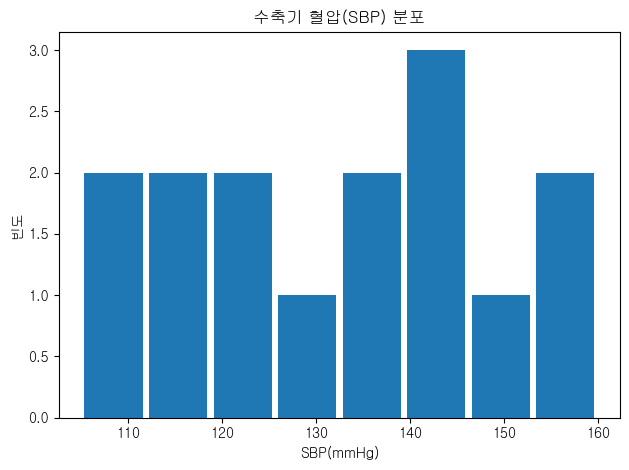

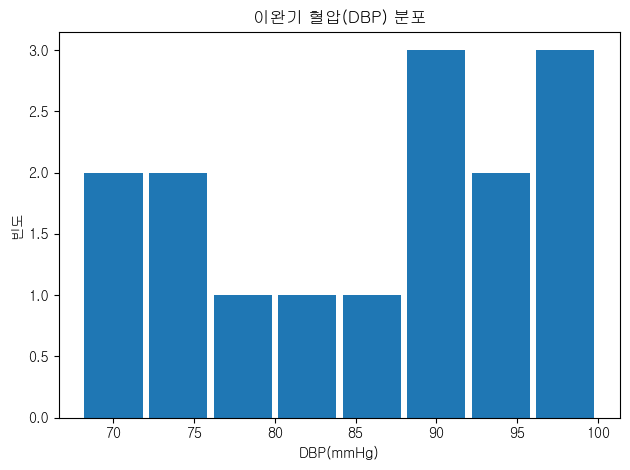

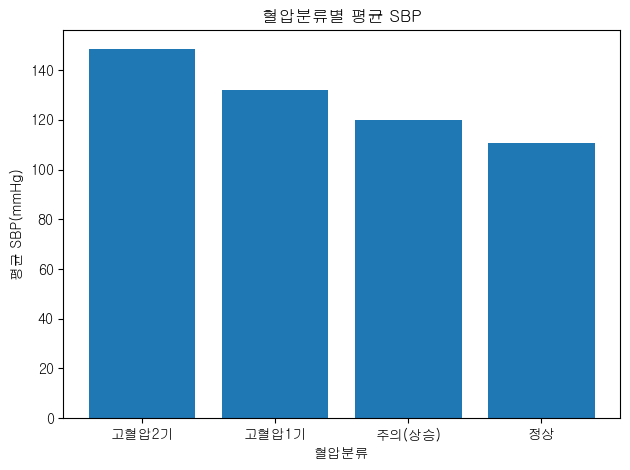

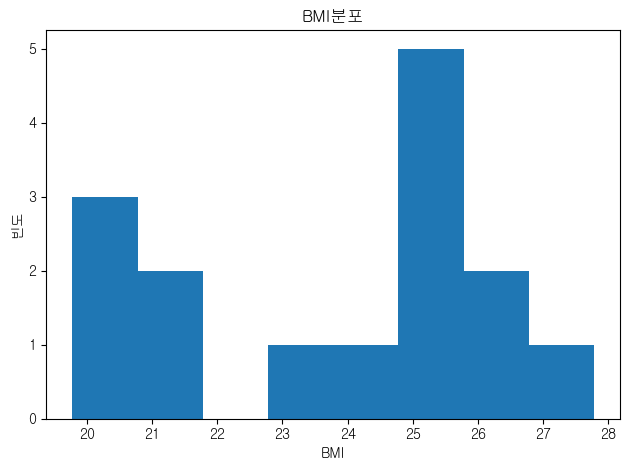

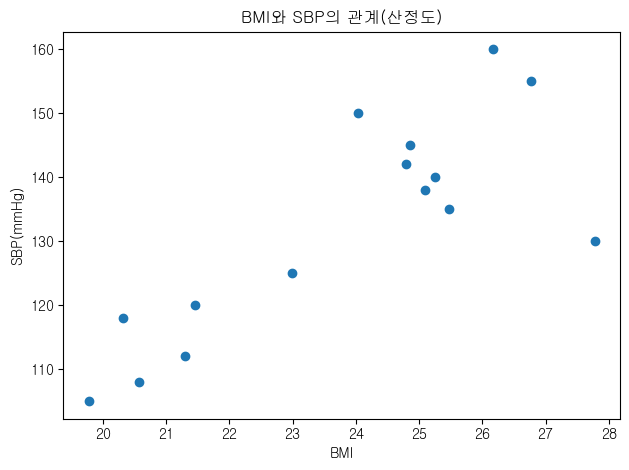

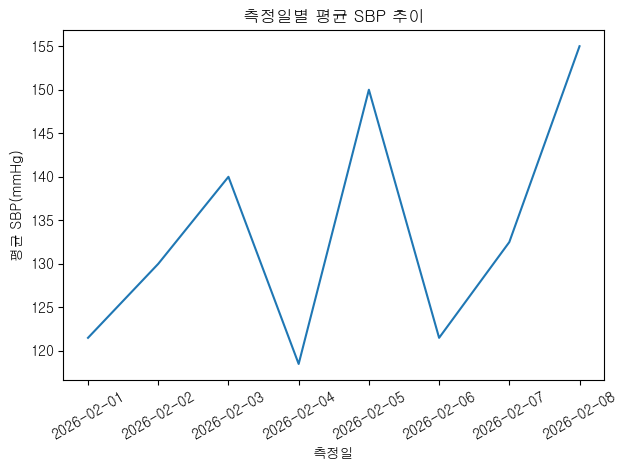

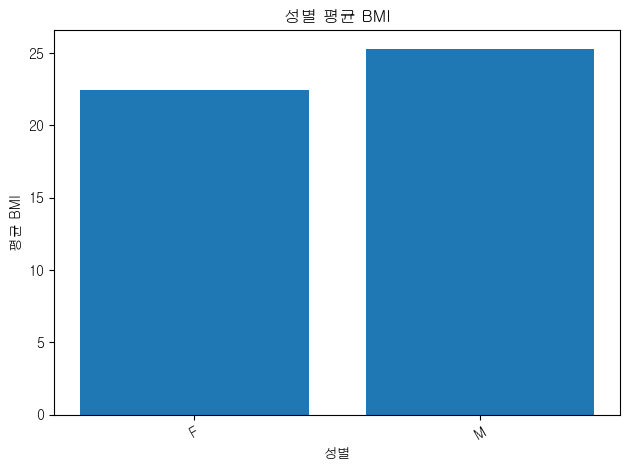

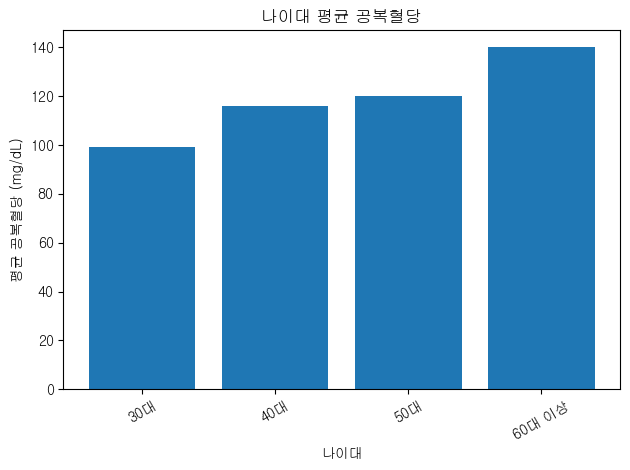

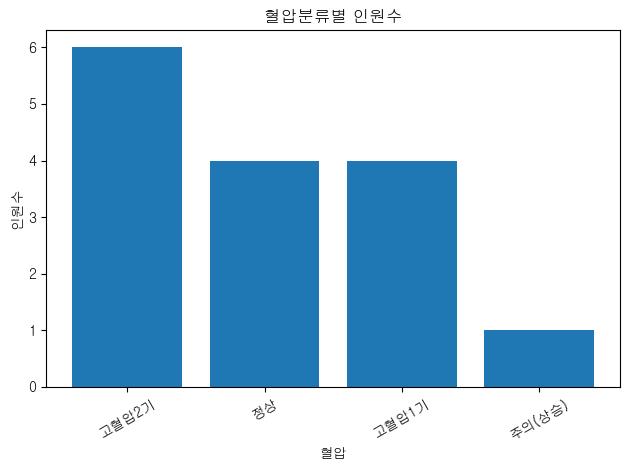

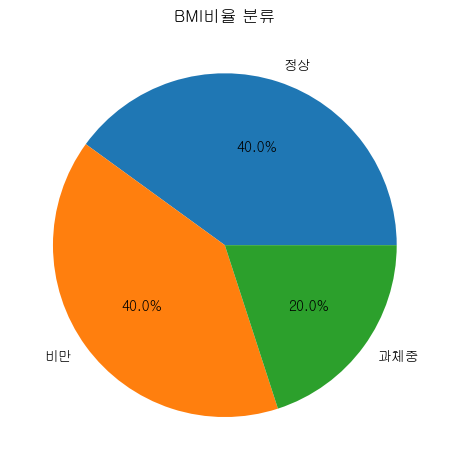

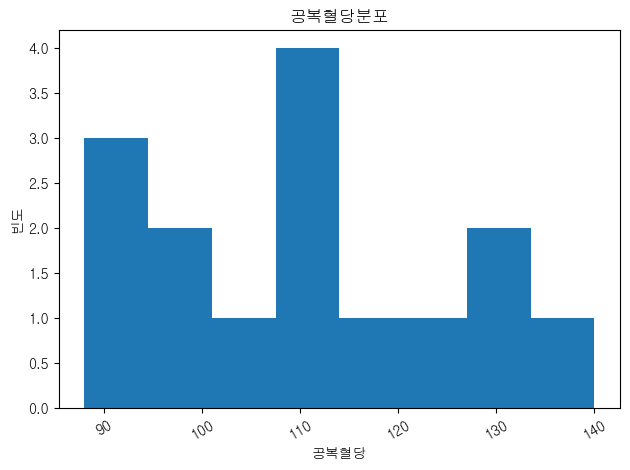

<Figure size 640x480 with 0 Axes>

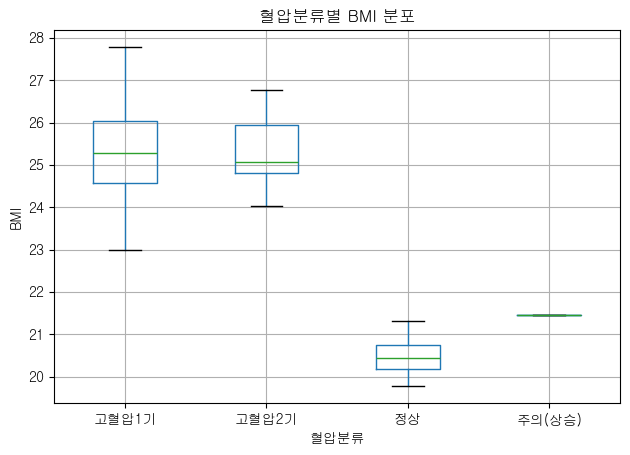

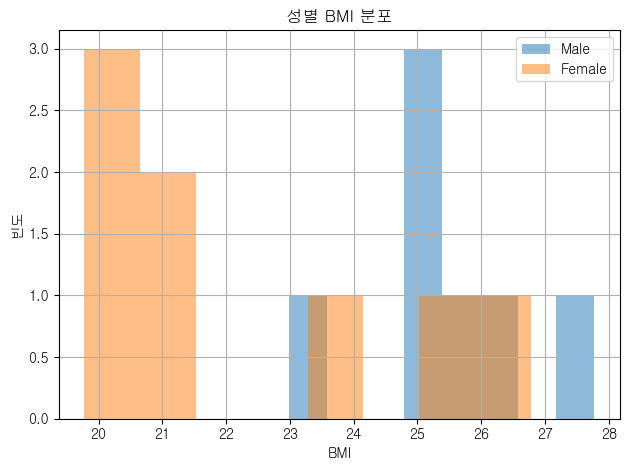

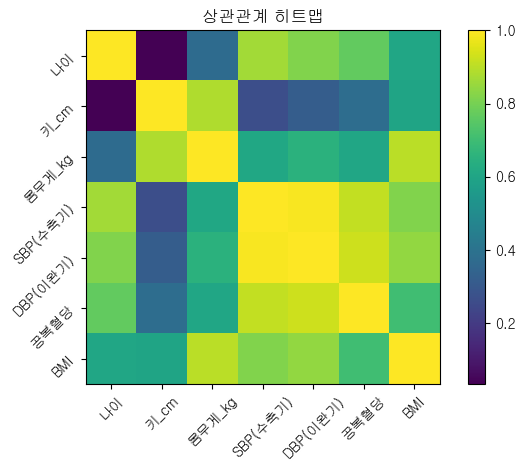

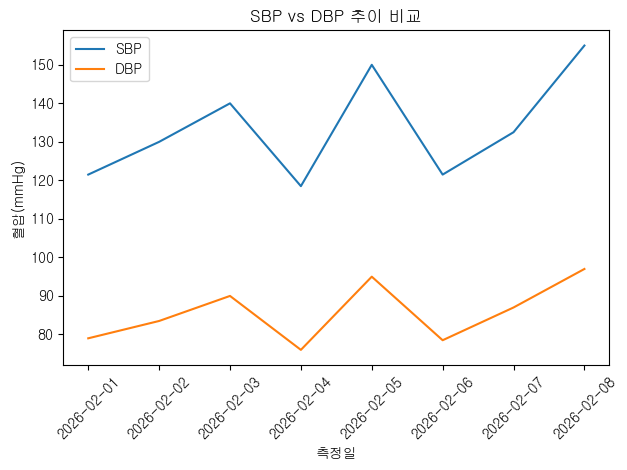

In [110]:
import matplotlib
import matplotlib.font_manager as fm

# 원하는 폰트 파일 경로 문자열로 입력
font_location = "C:\\Windows\\Fonts\\gulim.ttc"

# 지정한 폰트 파일 경로에서 폰트 추출
fontname = fm.FontProperties(fname=font_location).get_name()

# matplotlib의 전역 폰트 설정 변경
matplotlib.rc('font', family=fontname)

# ==============================
# [5] 시각화
# ==============================
print("==============================")
print("5) 시각화")
print("==============================")

# ---------------------------------------------
# 5-1) 혈압(SBP/DBP) 분포 히스토그램
# ---------------------------------------------
'''
히스토그램
- 숫자 데이터가 어느 구간에 얼마나 많이 모여 있는지 보여주는 그래프
- bins가 크면 클 수록 나뉘는 구간이 촘촘함
- 구간 수에 따라 그래프 모양이 달라짐
'''

plt.figure() # 그래프 공간 생성
plt.hist(df["SBP(수축기)"], bins=8,rwidth=0.9) # 구간 설정
plt.title("수축기 혈압(SBP) 분포") # 그래프 위 제목
plt.xlabel("SBP(mmHg)") # 가로축 의미 설명
plt.ylabel("빈도") # 세로축 의미 설명
plt.tight_layout() # 글자가 잘리지 않게 자동 정렬
plt.show() # 그래프 출력

plt.figure()
plt.hist(df["DBP(이완기)"], bins=8,rwidth=0.9)
plt.title("이완기 혈압(DBP) 분포")
plt.xlabel("DBP(mmHg)")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-2) 혈압분류별 평균 SBP 막대그래프
# ---------------------------------------------
bp_sbp_mean = df.groupby("혈압분류")["SBP(수축기)"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(bp_sbp_mean.index, bp_sbp_mean.values)
plt.title("혈압분류별 평균 SBP")
plt.xlabel("혈압분류")
plt.ylabel("평균 SBP(mmHg)")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-3) BMI 분포 히스토그램
# ---------------------------------------------
plt.figure()
plt.hist(df["BMI"],bins = 8)
plt.title("BMI분포")
plt.xlabel("BMI")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-4) 산정도 : BMI vs SBP 
# ---------------------------------------------

'''
산정도 : 두 개의 숫자 변수 관계를 점(dot)으로 표현한 그래프 
'''
plt.figure()
plt.scatter(df['BMI'],df ["SBP(수축기)"])
plt.title("BMI와 SBP의 관계(산정도)")
plt.xlabel("BMI")
plt.ylabel("SBP(mmHg)")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-5) 측정일 기준 SBP 추이(날짜별 평균)
# ---------------------------------------------
date_sbp =df.groupby("측정일")["SBP(수축기)"].mean()

plt.figure()
plt.plot(date_sbp.index, date_sbp.values)
plt.title("측정일별 평균 SBP 추이")
plt.xlabel("측정일")
plt.ylabel("평균 SBP(mmHg)")
plt.xticks(rotation=30) # x축 눈금(ticks) : 글자가 길 때
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-6)성별 평균  BMI 비교 
# ---------------------------------------------
gender_bmi_mean = df.groupby("성별")["BMI"].mean()

plt.figure()
plt.bar(gender_bmi_mean.index, gender_bmi_mean.values)
plt.title("성별 평균 BMI")
plt.xlabel("성별")
plt.ylabel("평균 BMI")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
# ---------------------------------------------
# 5-7)나이대 평균  BMI 비교 
# ---------------------------------------------
ages_glucose_mean = df.groupby("나이대")["공복혈당"].mean()

plt.figure()
plt.bar(ages_glucose_mean.index, ages_glucose_mean.values)
plt.title("나이대 평균 공복혈당")
plt.xlabel("나이대")
plt.ylabel("평균 공복혈당 (mg/dL)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-8) 혈압분류 인원수  
# ---------------------------------------------
bp_count = df["혈압분류"].value_counts()

plt.figure()
plt.bar(bp_count.index,bp_count.values)
plt.title("혈압분류별 인원수")
plt.xlabel("혈압")
plt.ylabel("인원수")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-9) BMI 분류 인원수 (파이차트)
# ---------------------------------------------
bmi_count = df["BMI분류"].value_counts()

plt.figure()
plt.pie(bmi_count.values, labels=bmi_count.index, autopct='%1.1f%%')
plt.title("BMI비율 분류")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-10)  공복혈당 분포 히스토그램
# --------------------------------------------
plt.figure()
plt.hist(df["공복혈당"],bins=8)
plt.title("공복혈당분포")
plt.xlabel("공복혈당")
plt.ylabel("빈도")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-11) 혈압분류별 BMI 분포 (박스플롯)
#  --------------------------------------------
'''
박스플롯 : 
-평균이 아니라 분포를 보여줌 
-이상치 확인이 가능함 
-평균 하나로는 확인이 부족할 때 퍼짐정도를 확인가능 
'''
plt.figure()
df.boxplot(column='BMI', by='혈압분류')
plt.title("혈압분류별 BMI 분포")
plt.suptitle('')   # 기본 제목 제거 (지저분해보이니까 우리가 정한 제목만 보이게)
plt.xlabel("혈압분류")
plt.ylabel("BMI")
plt.tight_layout()
plt.show() 

# ---------------------------------------------
# 5-12) 성별 BMI 
#  --------------------------------------------

plt.figure()

df[df['성별'] == 'M']['BMI'].hist(alpha=0.5, bins=8)
df[df['성별'] == 'F']['BMI'].hist(alpha=0.5, bins=8)

plt.title('성별 BMI 분포')
plt.xlabel('BMI')
plt.ylabel('빈도')
plt.legend(['Male', 'Female'])
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 5-13) 상관관계 히트맵
#  --------------------------------------------
'''
히트맵 
- 값의 크기를 색으로 표현하는 그래프 
'''
corr_cols = ['나이', '키_cm', '몸무게_kg', 'SBP(수축기)', 'DBP(이완기)', '공복혈당', 'BMI']
corr = df[corr_cols].corr()


plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.title('상관관계 히트맵')
plt.tight_layout()
plt.show()
# ---------------------------------------------
# 5-14) SBP vs DBP
#  --------------------------------------------
date_sbp = df.groupby('측정일')['SBP(수축기)'].mean()
date_dbp = df.groupby('측정일')['DBP(이완기)'].mean()


plt.figure()
plt.plot(date_sbp.index, date_sbp.values)
plt.plot(date_dbp.index, date_dbp.values)
plt.title('SBP vs DBP 추이 비교')
plt.xlabel('측정일')
plt.ylabel('혈압(mmHg)')
plt.legend(['SBP', 'DBP'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()